# Predicting the Economic Impacts of Climate Change on Agriculture Using Clustering Analysis and Machine Learning Techniques Learning (ML) techniques.

#                                                          Ziyun Qiao

## 1.Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [ ]:
!python --version


Python 3.13.5


In [ ]:
import sys
import sklearn
import xgboost
import pandas
import numpy

print(sys.version)
print(sklearn.__version__)
print(xgboost.__version__)
print(pandas.__version__)
print(numpy.__version__)

3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
1.6.1
3.2.0
2.2.3
2.1.3


In [ ]:
import matplotlib
import seaborn

print(matplotlib.__version__)
print(seaborn.__version__)

3.10.0
0.13.2


## 2.Load Dataset

In [ ]:
file_path = "climate_change_impact_on_agriculture_2024.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")


Dataset loaded successfully.


In [ ]:
df.rename(columns={

    "Average_Temperature_C": "Temperature",

    "Total_Precipitation_mm": "Rainfall",

    "CO2_Emissions_MT": "CO2",

    "Crop_Yield_MT_per_HA": "Yield",

    "Extreme_Weather_Events": "ExtremeEvents",

    "Irrigation_Access_%": "Irrigation",

    "Pesticide_Use_KG_per_HA": "Pesticide",

    "Fertilizer_Use_KG_per_HA": "Fertilizer",

    "Soil_Health_Index": "SoilHealth",

    "Economic_Impact_Million_USD": "EconomicImpact"

}, inplace=True)

In [ ]:
print("First 5 rows of training dataset:")
df.head()

First 5 rows of training dataset:


,Year,Country,Region,Crop_Type,Temperature,Rainfall,CO2,Yield,ExtremeEvents,Irrigation,Pesticide,Fertilizer,SoilHealth,Adaptation_Strategies,EconomicImpact
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22
2,2001,France,Ile-de-France,Wheat,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,67.78,Water Management,796.96
3,2001,Canada,Prairies,Coffee,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,91.39,No Adaptation,790.32
4,1998,India,Tamil Nadu,Sugarcane,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,49.61,Crop Rotation,401.72


In [ ]:
print("Last 5 rows of training dataset:")
df.tail()

Last 5 rows of training dataset:


,Year,Country,Region,Crop_Type,Temperature,Rainfall,CO2,Yield,ExtremeEvents,Irrigation,Pesticide,Fertilizer,SoilHealth,Adaptation_Strategies,EconomicImpact
9995,2022,France,Nouvelle-Aquitaine,Cotton,30.48,685.93,17.64,3.033,9,27.56,41.96,10.95,43.41,No Adaptation,1483.06
9996,1999,Australia,Queensland,Soybeans,9.53,2560.38,10.68,2.560,4,77.02,5.45,82.32,59.39,No Adaptation,829.61
9997,2000,Argentina,Patagonia,Coffee,31.92,357.76,26.01,1.161,10,78.53,11.94,26.00,41.46,Water Management,155.99
9998,1996,Brazil,Southeast,Soybeans,13.95,1549.52,17.31,3.348,2,42.65,44.71,25.07,75.10,Crop Rotation,1613.90
9999,2015,China,South,Corn,11.78,1676.25,5.34,3.710,5,46.41,48.28,98.27,59.38,Water Management,453.14


In [ ]:
summary_table = pd.DataFrame({
    "Item": [
        "Number of rows",
        "Number of columns",
        "Number of numerical columns",
        "Number of categorical columns",
        "Number of duplicated rows",
        "Target variable"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.select_dtypes(include=["int64", "float64"]).shape[1],
        df.select_dtypes(include=["object"]).shape[1],
        df.duplicated().sum(),
        "EconomicImpact"
    ]
})

summary_table

,Item,Value
0,Number of rows,10000
1,Number of columns,15
2,Number of numerical columns,11
3,Number of categorical columns,4
4,Number of duplicated rows,0
5,Target variable,EconomicImpact


In [ ]:
df.columns

Index(['Year', 'Country', 'Region', 'Crop_Type', 'Temperature', 'Rainfall',
       'CO2', 'Yield', 'ExtremeEvents', 'Irrigation', 'Pesticide',
       'Fertilizer', 'SoilHealth', 'Adaptation_Strategies', 'EconomicImpact'],
      dtype='object')

In [ ]:
# Data Types Table

data_types_table = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Number of Unique Values": df.nunique().values,
    "Missing Values": df.isnull().sum().values
})

data_types_table

,Variable,Data Type,Number of Unique Values,Missing Values
0,Year,int64,35,0
1,Country,object,10,0
2,Region,object,34,0
3,Crop_Type,object,10,0
4,Temperature,float64,3677,0
5,Rainfall,float64,9784,0
6,CO2,float64,2852,0
7,Yield,float64,850,0
8,ExtremeEvents,int64,11,0
9,Irrigation,float64,6003,0


## 3.Basic Data Cleaning

### 3.1 Dataset Overview

In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset Shape:
(10000, 15)

Columns:
['Year', 'Country', 'Region', 'Crop_Type', 'Temperature', 'Rainfall', 'CO2', 'Yield', 'ExtremeEvents', 'Irrigation', 'Pesticide', 'Fertilizer', 'SoilHealth', 'Adaptation_Strategies', 'EconomicImpact']


### 3.2 Data Types Inspection

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   10000 non-null  int64  
 1   Country                10000 non-null  object 
 2   Region                 10000 non-null  object 
 3   Crop_Type              10000 non-null  object 
 4   Temperature            10000 non-null  float64
 5   Rainfall               10000 non-null  float64
 6   CO2                    10000 non-null  float64
 7   Yield                  10000 non-null  float64
 8   ExtremeEvents          10000 non-null  int64  
 9   Irrigation             10000 non-null  float64
 10  Pesticide              10000 non-null  float64
 11  Fertilizer             10000 non-null  float64
 12  SoilHealth             10000 non-null  float64
 13  Adaptation_Strategies  10000 non-null  object 
 14  EconomicImpact         10000 non-null  float64
dtypes: 

### 3.3 Missing Values Analysis

In [ ]:
# Missing Values Check

missing_values = pd.DataFrame({
    "Variable": df.columns,
    "Missing Count": df.isnull().sum().values,
    "Missing Percentage (%)": (df.isnull().sum().values / len(df) * 100).round(2)
})

missing_values = missing_values.sort_values(by="Missing Count", ascending=False)

missing_values

,Variable,Missing Count,Missing Percentage (%)
0,Year,0,0.0
1,Country,0,0.0
2,Region,0,0.0
3,Crop_Type,0,0.0
4,Temperature,0,0.0
5,Rainfall,0,0.0
6,CO2,0,0.0
7,Yield,0,0.0
8,ExtremeEvents,0,0.0
9,Irrigation,0,0.0


In [ ]:
print(df.isnull().sum().sum())

0


### 3.4 Duplicate Records Detection

In [ ]:
# Duplicate Rows Check
duplicate_count = df.duplicated().sum()

print(
    "Duplicate Records:",
    duplicate_count
)

Duplicate Records: 0


### 3.5 Descriptive Statistics

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,10000.0,2007.088700,10.084245,1990.00,1999.0000,2007.000,2016.0000,2024.00
Temperature,10000.0,15.241299,11.466955,-4.99,5.4300,15.175,25.3400,35.00
Rainfall,10000.0,1611.663834,805.016815,200.15,925.6975,1611.160,2306.9975,2999.67
CO2,10000.0,15.246608,8.589423,0.50,7.7600,15.200,22.8200,30.00
Yield,10000.0,2.240017,0.998342,0.45,1.4490,2.170,2.9300,5.00
ExtremeEvents,10000.0,4.980900,3.165808,0.00,2.0000,5.000,8.0000,10.00
Irrigation,10000.0,55.248332,25.988305,10.01,32.6775,55.175,77.5825,99.99
Pesticide,10000.0,24.955735,14.490962,0.00,12.5275,24.930,37.4700,49.99
Fertilizer,10000.0,49.973708,28.711027,0.01,25.3900,49.635,74.8250,99.99
SoilHealth,10000.0,64.901278,20.195882,30.00,47.2350,64.650,82.4725,100.00


### 3.6 Outlier Detection

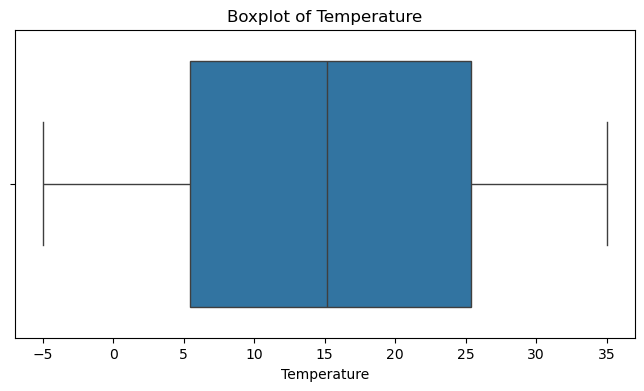

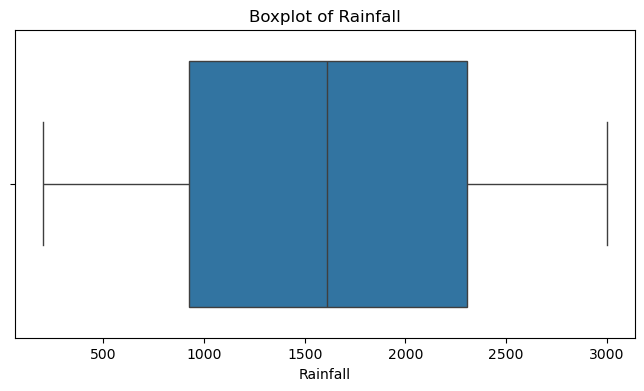

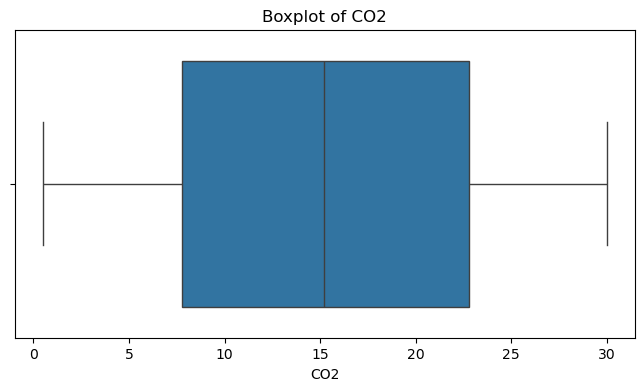

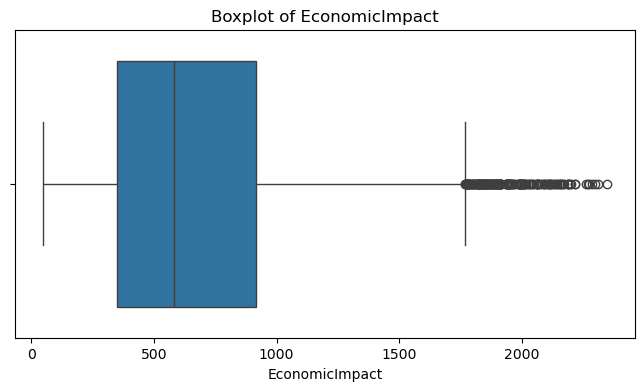

In [ ]:
numerical_cols = [
    "Temperature",
    "Rainfall",
    "CO2",
    "EconomicImpact"
]

for col in numerical_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(
        f"Boxplot of {col}"
    )

    plt.show()

### 3.7 Check Category Levels

In [ ]:
categorical_cols = [
    "Country",
    "Region",
    "Crop_Type",
    "Adaptation_Strategies"
]

for col in categorical_cols:

    print(
        col,
        ":",
        df[col].nunique()
    )

Country : 10
Region : 34
Crop_Type : 10
Adaptation_Strategies : 5


### 3.8 Encoding Categorical Variables

In [ ]:
df_model = pd.get_dummies(
    df,
    columns=[
        "Country",
        "Region",
        "Crop_Type",
        "Adaptation_Strategies"
    ],
    drop_first=True
)

print(
    df_model.shape
)

(10000, 66)


### 3.9 Feature Scaling for Clustering

In [ ]:
cluster_features = [
    "Temperature",
    "Rainfall",
    "CO2",
    "ExtremeEvents",
    "Irrigation",
    "SoilHealth"
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df[cluster_features]
)

## 4. EDA

### 4.1 Frequency Distributions of Numerical Variables

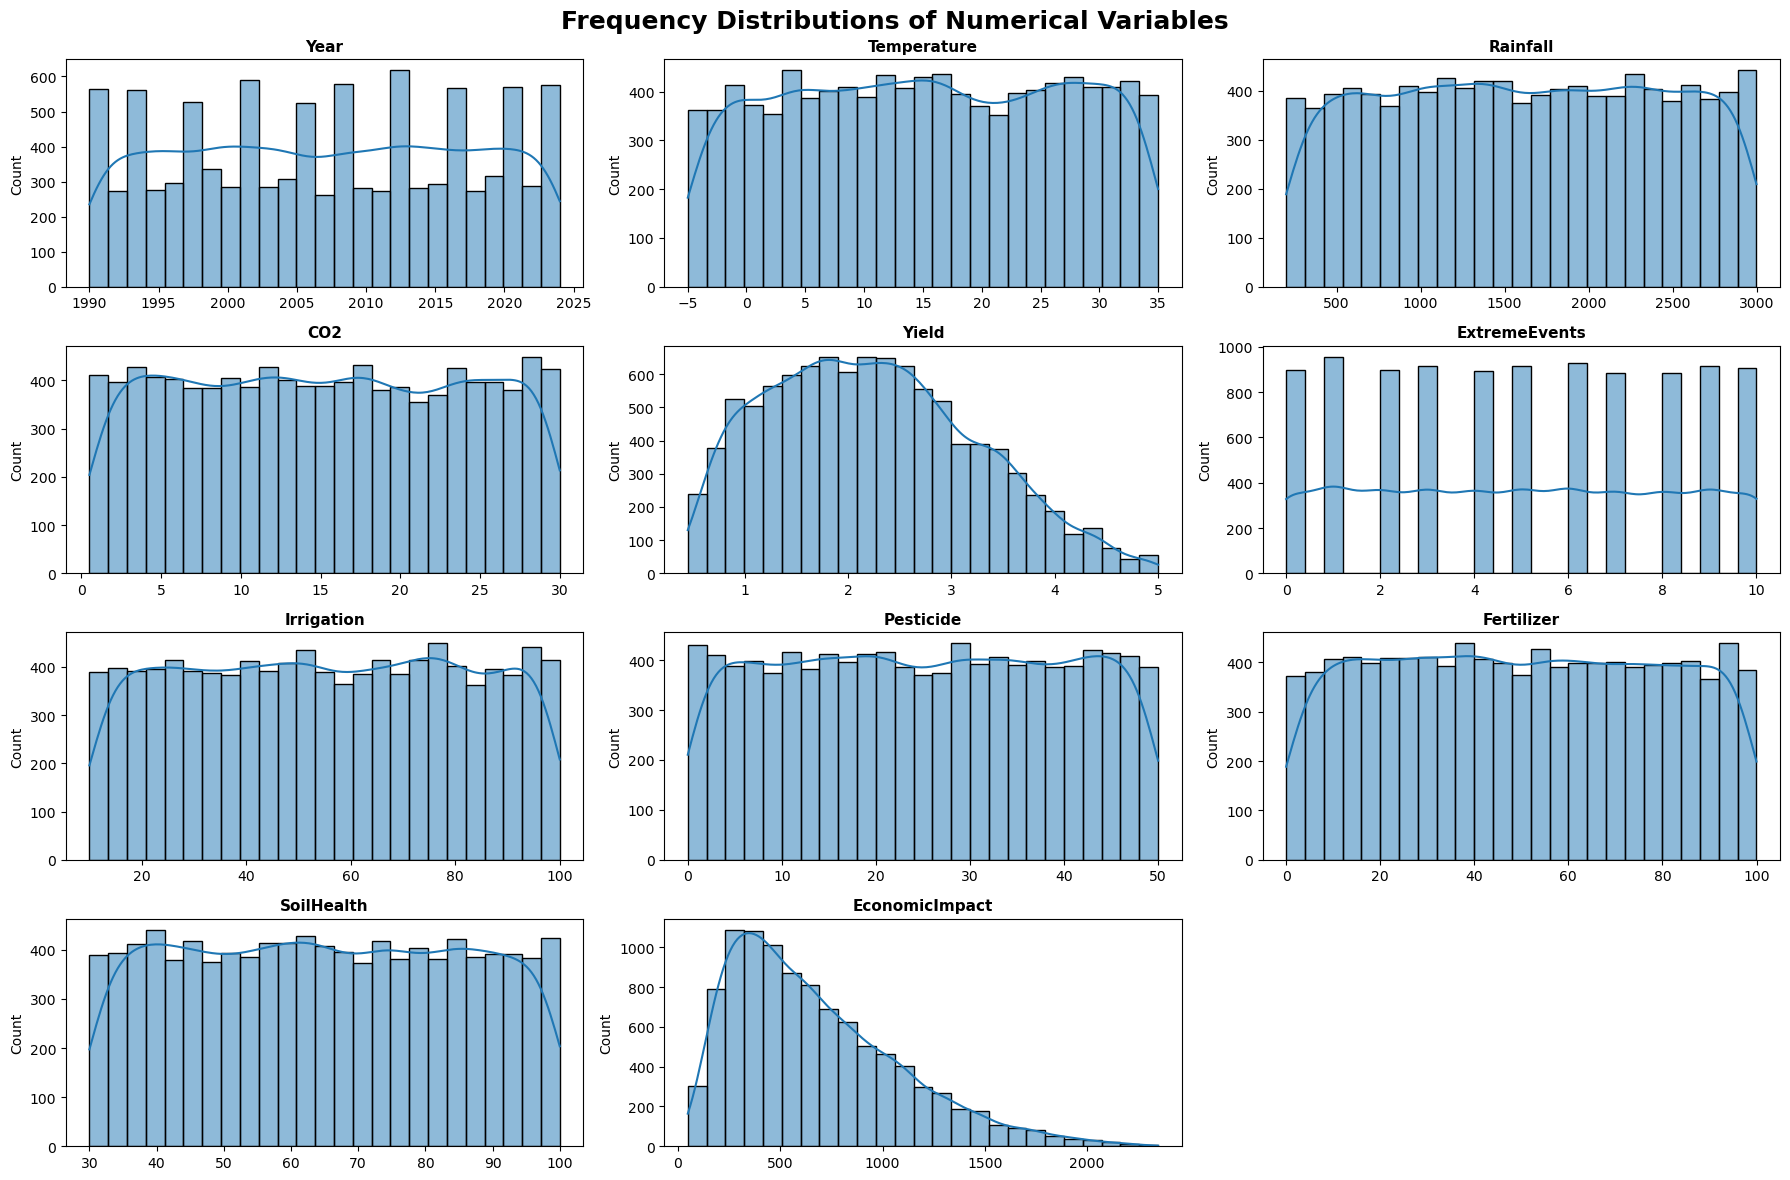

In [ ]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

n_cols = 3
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 12)
)

axes = axes.flatten()

for i, col in enumerate(numeric_columns):

    sns.histplot(
        data=df,
        x=col,
        bins=25,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(
        col,
        fontsize=11,
        fontweight="bold"
    )

    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Frequency Distributions of Numerical Variables",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### 4.2 Economic Impact Distribution

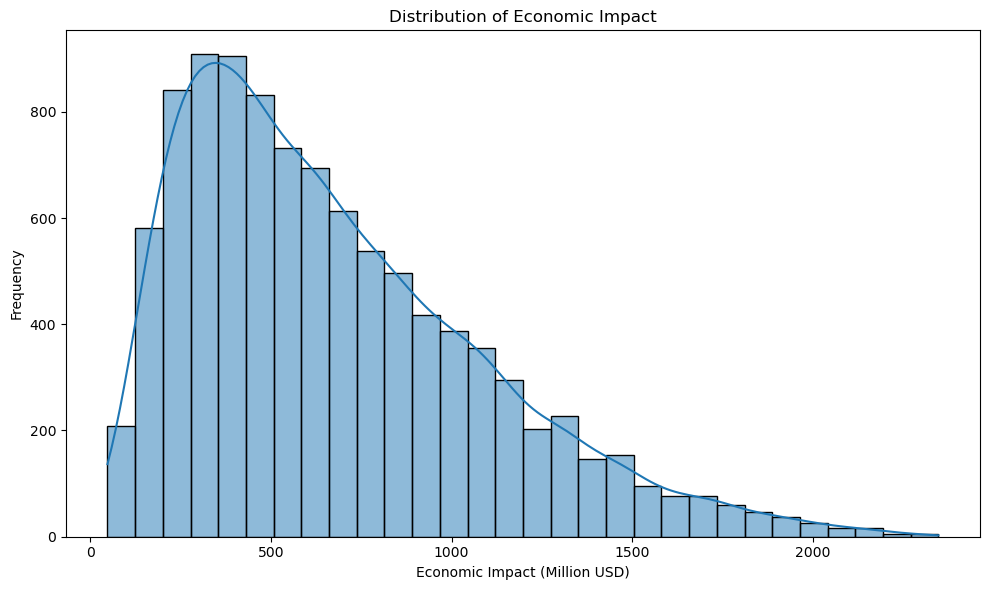

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["EconomicImpact"],
    bins=30,
    kde=True
)

plt.title("Distribution of Economic Impact")
plt.xlabel("Economic Impact (Million USD)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

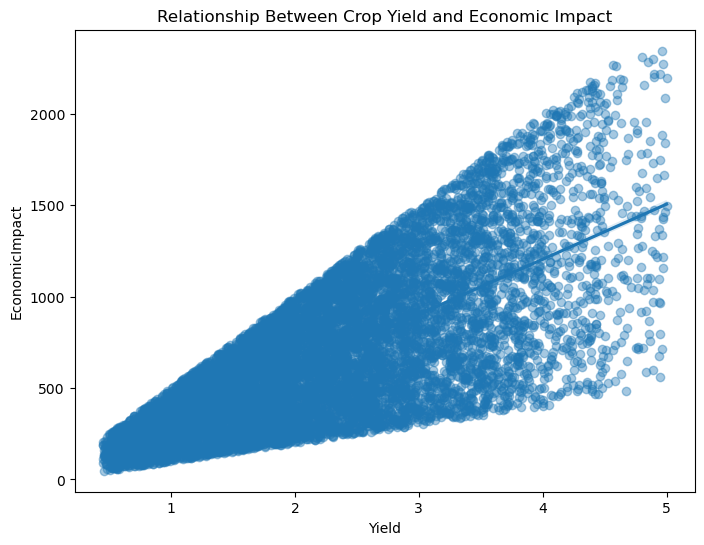

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Yield",
    y="EconomicImpact",
    scatter_kws={"alpha":0.4}
)

plt.title(
    "Relationship Between Crop Yield and Economic Impact"
)

plt.show()

### 4.3 Correlation Heatmap

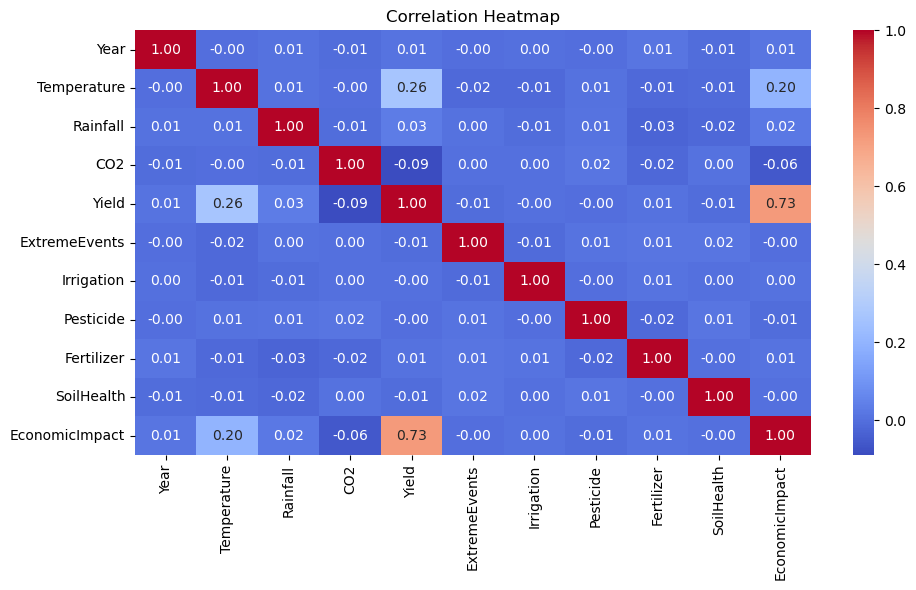

In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


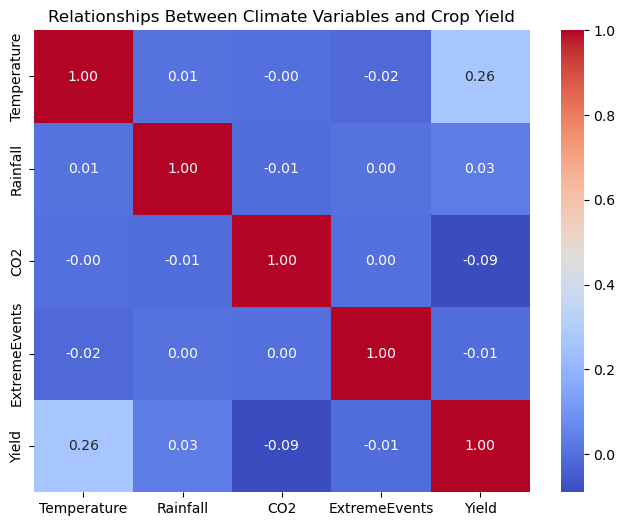

In [ ]:
plt.figure(figsize=(8,6))

corr_cols = [
    "Temperature",
    "Rainfall",
    "CO2",
    "ExtremeEvents",
    "Yield"
]

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Relationships Between Climate Variables and Crop Yield"
)

plt.show()

### 4.4 Scatter Relationships

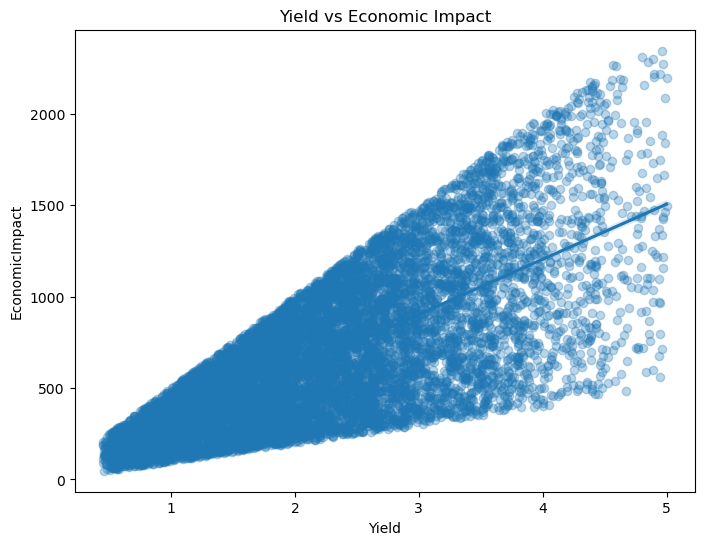

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Yield",
    y="EconomicImpact",
    scatter_kws={"alpha":0.3}
)

plt.title(
    "Yield vs Economic Impact"
)

plt.show()

### 4.5 Climate Variable Relationships

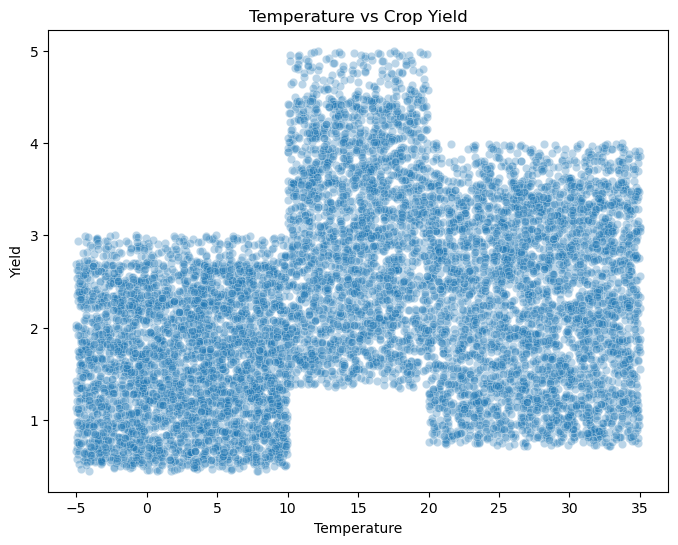

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Temperature",
    y="Yield",
    alpha=0.3
)

plt.title(
    "Temperature vs Crop Yield"
)

plt.show()

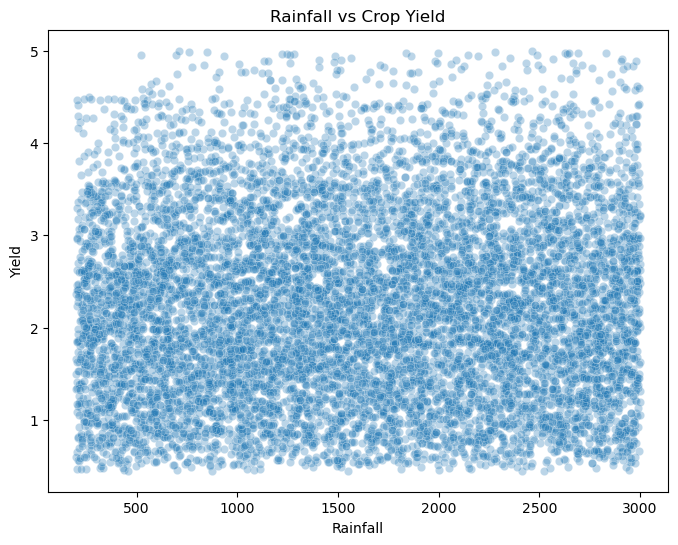

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Rainfall",
    y="Yield",
    alpha=0.3
)

plt.title(
    "Rainfall vs Crop Yield"
)

plt.show()

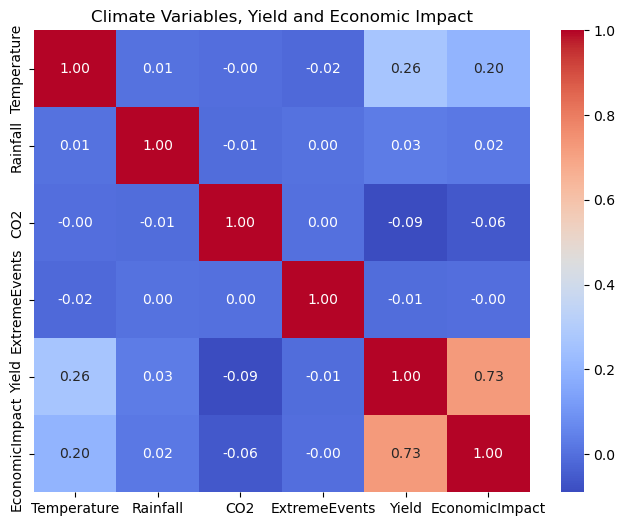

In [ ]:
corr_cols = [
    "Temperature",
    "Rainfall",
    "CO2",
    "ExtremeEvents",
    "Yield",
    "EconomicImpact"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Climate Variables, Yield and Economic Impact"
)

plt.show()

## 5. K-Means Clustering

### 5.1 Select Cluster Features

In [ ]:
cluster_features = [
    "Temperature",
    "Rainfall",
    "CO2",
    "ExtremeEvents",
    "Irrigation",
    "SoilHealth"
]

X_cluster = df[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

X_scaled.shape

(10000, 6)

### 5.2 Elbow Method

  File "e:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "e:\anaconda\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "e:\anaconda\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\anaconda\Lib\subprocess.py", line 1554, in _execute_child
    hp, ht, pid, t

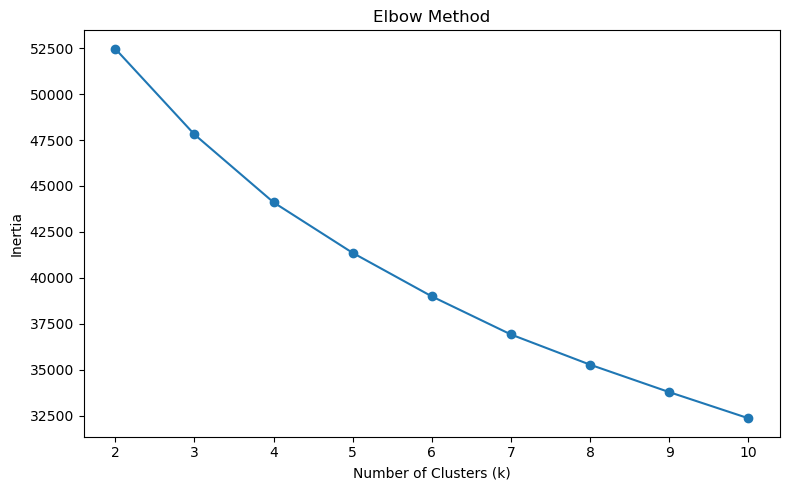

In [ ]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.tight_layout()
plt.show()

### 5.3 Silhouette Analysis

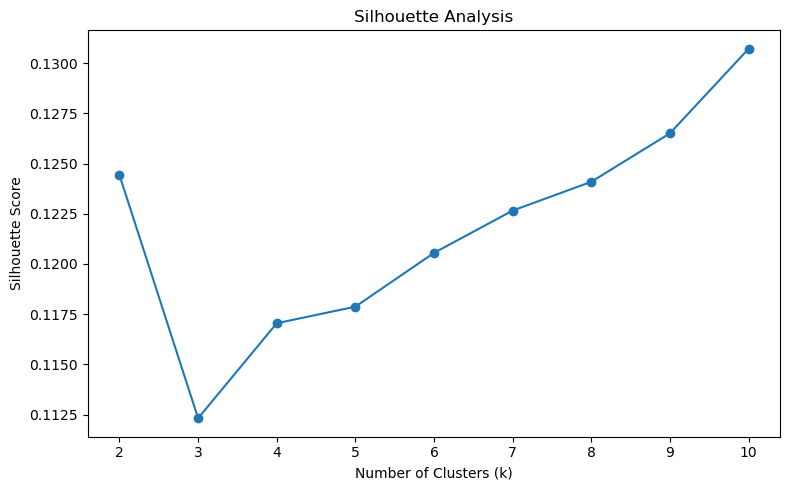

In [ ]:
silhouette_scores = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        labels
    )
    
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(K, silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.tight_layout()
plt.show()

### 5.4 Final KMeans Model

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df["Cluster"].value_counts().sort_index()

Cluster
0    2495
1    2484
2    2467
3    2554
Name: count, dtype: int64

Cluster 0
High temperature
Low rainfall

Cluster 1
Moderate temperature
High rainfall

Cluster 2
Extreme climate conditions

Cluster 3
Relatively stable climate

## 6. Cluster Analysis

### 6.1 PCA Visualisation

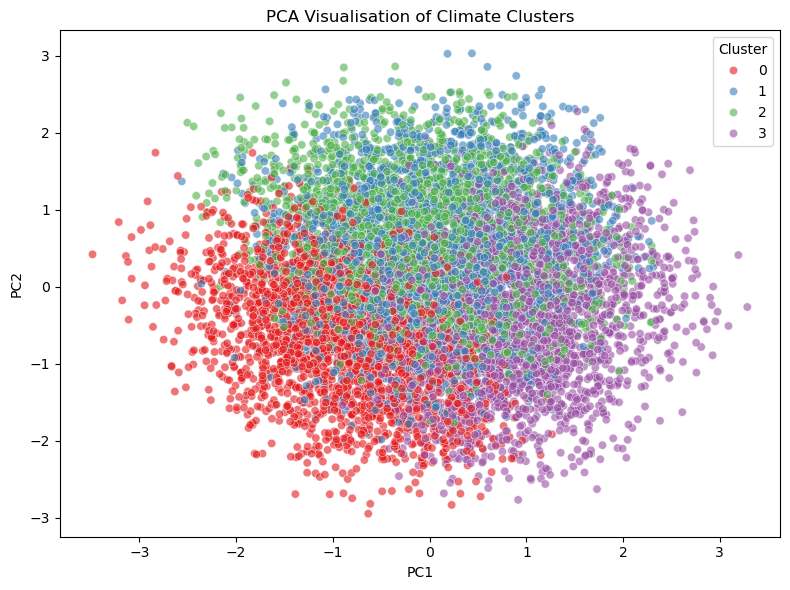

In [ ]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": pca_result[:, 0],
    "PC2": pca_result[:, 1],
    "Cluster": df["Cluster"]
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    alpha=0.6
)

plt.title("PCA Visualisation of Climate Clusters")
plt.tight_layout()
plt.show()

### 6.2 Cluster Summary Table

In [ ]:
cluster_summary = df.groupby("Cluster")[
    [
        "Temperature",
        "Rainfall",
        "CO2",
        "ExtremeEvents",
        "Irrigation",
        "SoilHealth",
        "EconomicImpact"
    ]
].mean()

cluster_summary.round(2)

,Temperature,Rainfall,CO2,ExtremeEvents,Irrigation,SoilHealth,EconomicImpact
Cluster,,,,,,,
0,24.69,1671.69,14.83,1.98,54.02,61.10,744.14
1,5.56,2358.25,15.31,5.19,56.26,65.07,605.32
2,24.52,1616.83,15.62,8.02,53.66,66.10,746.85
3,6.47,821.90,15.24,4.78,57.00,67.29,602.97


### 6.3 Cluster Heatmap

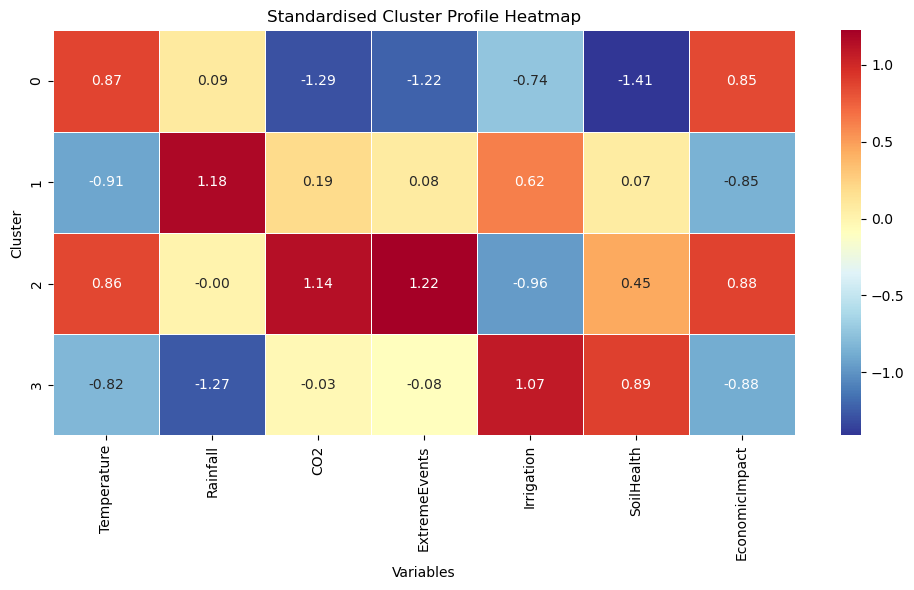

In [ ]:
cluster_profile = cluster_summary.copy()

cluster_profile_scaled = (
    cluster_profile - cluster_profile.mean()
) / cluster_profile.std()

rename_dict = {
    "Average_Temperature_C": "Temperature",
    "Total_Precipitation_mm": "Precipitation",
    "CO2_Emissions_MT": "CO2",
    "Extreme_Weather_Events": "Extreme Events",
    "Irrigation_Access_%": "Irrigation",
    "Soil_Health_Index": "Soil Health",
    "Economic_Impact_Million_USD": "Economic Impact"
}

cluster_profile_scaled = cluster_profile_scaled.rename(
    columns=rename_dict
)

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_profile_scaled,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    linewidths=0.5
)

plt.title("Standardised Cluster Profile Heatmap")
plt.xlabel("Variables")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

### 6.4 Cluster Size

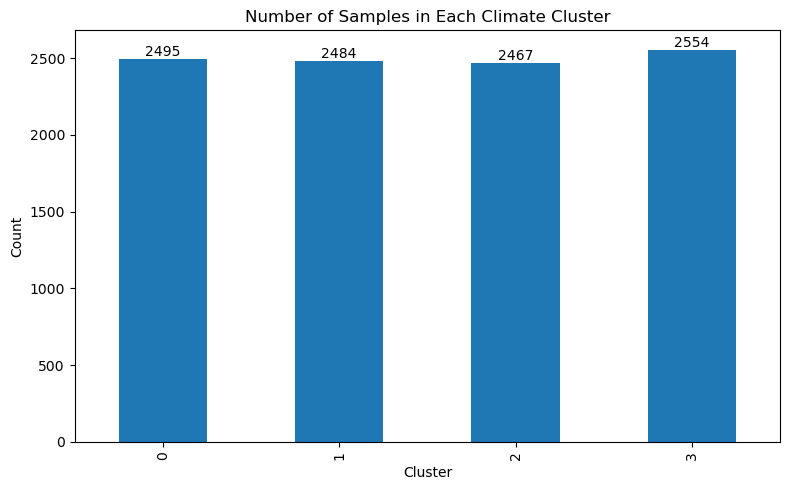

In [ ]:
cluster_counts = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8,5))

ax = cluster_counts.plot(kind="bar")

plt.title("Number of Samples in Each Climate Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")

for i, v in enumerate(cluster_counts):
    plt.text(i, v + 20, str(v), ha="center")

plt.tight_layout()
plt.show()

### 6.5 Economic Impact by Cluster

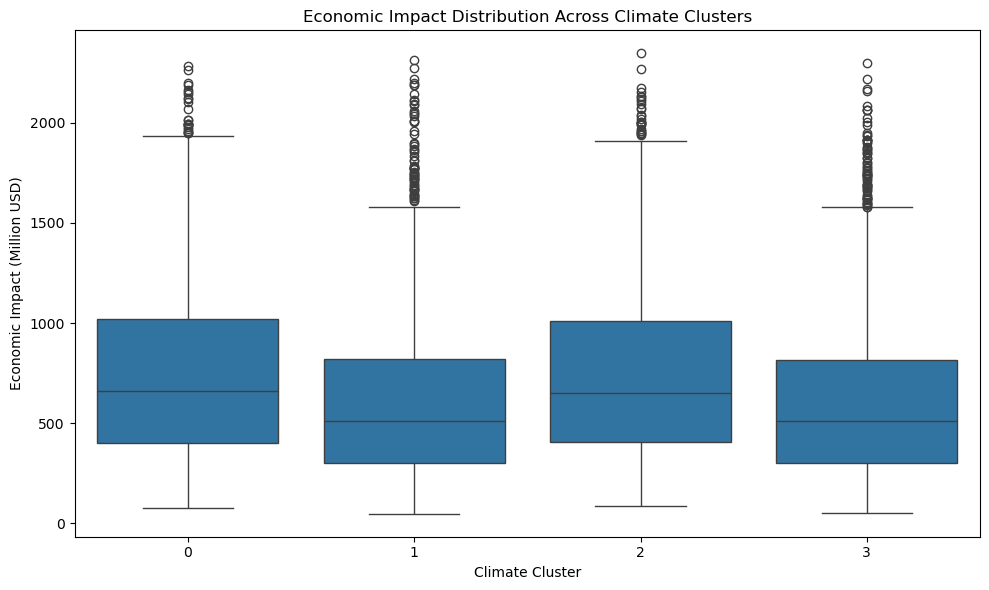

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Cluster",
    y="EconomicImpact"
)

plt.title("Economic Impact Distribution Across Climate Clusters")
plt.xlabel("Climate Cluster")
plt.ylabel("Economic Impact (Million USD)")

plt.tight_layout()
plt.show()

### 6.6 Cluster Interpretation

In [ ]:
interpretation_table = cluster_summary.copy()

interpretation_table["Temperature_Level"] = np.where(
    interpretation_table["Temperature"] >
    interpretation_table["Temperature"].mean(),
    "High",
    "Low"
)

interpretation_table["Rainfall_Level"] = np.where(
    interpretation_table["Rainfall"] >
    interpretation_table["Rainfall"].mean(),
    "High",
    "Low"
)

interpretation_table["ExtremeEvents_Level"] = np.where(
    interpretation_table["ExtremeEvents"] >
    interpretation_table["ExtremeEvents"].mean(),
    "High",
    "Low"
)

interpretation_table["EconomicImpact_Level"] = np.where(
    interpretation_table["EconomicImpact"] >
    interpretation_table["EconomicImpact"].mean(),
    "High",
    "Low"
)

interpretation_table[
    [
        "Temperature_Level",
        "Rainfall_Level",
        "ExtremeEvents_Level",
        "EconomicImpact_Level"
    ]
]

,Temperature_Level,Rainfall_Level,ExtremeEvents_Level,EconomicImpact_Level
Cluster,,,,
0,High,High,Low,High
1,Low,High,High,Low
2,High,Low,High,High
3,Low,Low,Low,Low


In [ ]:
for cluster in cluster_summary.index:

    temp = cluster_summary.loc[cluster, "Temperature"]
    rain = cluster_summary.loc[cluster, "Rainfall"]
    extreme = cluster_summary.loc[cluster, "ExtremeEvents"]
    impact = cluster_summary.loc[cluster, "EconomicImpact"]

    print(f"\nCluster {cluster}")

    print(
        f"Average Temperature = {temp:.2f} °C, "
        f"Rainfall = {rain:.2f} mm, "
        f"Extreme Events = {extreme:.2f}, "
        f"Economic Impact = {impact:.2f}"
    )


Cluster 0
Average Temperature = 24.69 °C, Rainfall = 1671.69 mm, Extreme Events = 1.98, Economic Impact = 744.14

Cluster 1
Average Temperature = 5.56 °C, Rainfall = 2358.25 mm, Extreme Events = 5.19, Economic Impact = 605.32

Cluster 2
Average Temperature = 24.52 °C, Rainfall = 1616.83 mm, Extreme Events = 8.02, Economic Impact = 746.85

Cluster 3
Average Temperature = 6.47 °C, Rainfall = 821.90 mm, Extreme Events = 4.78, Economic Impact = 602.97


## 7. Prepare Modelling Dataset

In [ ]:
df_model = pd.get_dummies(
    df,
    columns=[
        "Country",
        "Region",
        "Crop_Type",
        "Adaptation_Strategies"
    ],
    drop_first=True
)

print("Dataset shape:", df_model.shape)

print("\nCluster column check:")
print([c for c in df_model.columns if "Cluster" in c])

Dataset shape: (10000, 67)

Cluster column check:
['Cluster']


In [ ]:
target = "EconomicImpact"

X_without_cluster = df_model.drop(
    columns=[target, "Cluster"]
)

X_with_cluster = df_model.drop(
    columns=[target]
)

y = df_model[target]

print("Without Cluster:", X_without_cluster.shape)
print("With Cluster:", X_with_cluster.shape)
print("Target:", y.shape)

Without Cluster: (10000, 65)
With Cluster: (10000, 66)
Target: (10000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_without_cluster,
    y,
    test_size=0.2,
    random_state=42
)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_with_cluster,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train_nc.shape)
print(X_test_nc.shape)
print(X_train_c.shape)
print(X_test_c.shape)

(8000, 65)
(2000, 65)
(8000, 66)
(2000, 66)


## 8. Machine Learning Models

### 8.1 Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_c, y_train_c)

lr_pred = lr.predict(X_test_c)

lr_mae = mean_absolute_error(
    y_test_c,
    lr_pred
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test_c,
        lr_pred
    )
)

lr_r2 = r2_score(
    y_test_c,
    lr_pred
)

print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

MAE: 225.69104843011377
RMSE: 286.64755140948625
R2: 0.5444570675729495


### 8.2 Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt.fit(
    X_train_c,
    y_train_c
)

dt_pred = dt.predict(
    X_test_c
)

dt_mae = mean_absolute_error(
    y_test_c,
    dt_pred
)

dt_rmse = np.sqrt(
    mean_squared_error(
        y_test_c,
        dt_pred
    )
)

dt_r2 = r2_score(
    y_test_c,
    dt_pred
)

print("MAE:", dt_mae)
print("RMSE:", dt_rmse)
print("R2:", dt_r2)

MAE: 247.23471701943473
RMSE: 329.51927187252494
R2: 0.39800278916011433


### 8.3 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train_c,
    y_train_c
)

rf_pred = rf.predict(
    X_test_c
)

rf_mae = mean_absolute_error(
    y_test_c,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test_c,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test_c,
    rf_pred
)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

MAE: 226.36361125000002
RMSE: 290.180521004745
R2: 0.5331586107997779


### 8.4 Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05
)

gb.fit(
    X_train_c,
    y_train_c
)

gb_pred = gb.predict(
    X_test_c
)

gb_mae = mean_absolute_error(
    y_test_c,
    gb_pred
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test_c,
        gb_pred
    )
)

gb_r2 = r2_score(
    y_test_c,
    gb_pred
)

print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R2:", gb_r2)

MAE: 226.1249843282546
RMSE: 288.7073120209639
R2: 0.5378867648796846


### 8.5 XGBoost

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    objective="reg:squarederror"
)

xgb.fit(
    X_train_c,
    y_train_c
)

xgb_pred = xgb.predict(
    X_test_c
)

xgb_mae = mean_absolute_error(
    y_test_c,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test_c,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    y_test_c,
    xgb_pred
)

print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

MAE: 225.32176736389158
RMSE: 289.1004956202132
R2: 0.536627225818827


### 8.6 Neural Network

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

nn = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "mlp",
        MLPRegressor(
            hidden_layer_sizes=(64,64),
            activation="relu",
            max_iter=1000,
            random_state=42
        )
    )
])

nn.fit(
    X_train_c,
    y_train_c
)

nn_pred = nn.predict(
    X_test_c
)

nn_mae = mean_absolute_error(
    y_test_c,
    nn_pred
)

nn_rmse = np.sqrt(
    mean_squared_error(
        y_test_c,
        nn_pred
    )
)

nn_r2 = r2_score(
    y_test_c,
    nn_pred
)

print("MAE:", nn_mae)
print("RMSE:", nn_rmse)
print("R2:", nn_r2)

MAE: 302.87629667202066
RMSE: 382.6505974434468
R2: 0.18822133708683453


## 9 Experimental Results

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test
):

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    r2 = r2_score(
        y_test,
        pred
    )

    return mae, rmse, r2

In [ ]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42,
        max_depth=10
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_estimators=200
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42,
        n_estimators=200
    ),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR())
    ]),

    "XGBoost": XGBRegressor(
        random_state=42,
        n_estimators=200,
        objective="reg:squarederror"
    )
}

### 9.1 Without Cluster

In [ ]:
results_without = []

for name, model in models.items():

    mae, rmse, r2 = evaluate_model(
        model,
        X_train_nc,
        X_test_nc,
        y_train_nc,
        y_test_nc
    )

    results_without.append(
        [name, mae, rmse, r2]
    )

results_without = pd.DataFrame(
    results_without,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

results_without

,Model,MAE,RMSE,R2
0,Linear Regression,225.658077,286.620848,0.544542
1,Decision Tree,247.550201,329.836654,0.396843
2,Random Forest,226.432033,290.235051,0.532983
3,Gradient Boosting,226.953018,290.020585,0.533673
4,SVR,321.465357,420.916857,0.017742
5,XGBoost,243.258486,313.864238,0.453844


### 9.2 With Cluster

In [ ]:
results_with = []

for name, model in models.items():

    mae, rmse, r2 = evaluate_model(
        model,
        X_train_c,
        X_test_c,
        y_train_c,
        y_test_c
    )

    results_with.append(
        [name, mae, rmse, r2]
    )

results_with = pd.DataFrame(
    results_with,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

results_with

,Model,MAE,RMSE,R2
0,Linear Regression,225.691048,286.647551,0.544457
1,Decision Tree,247.234717,329.519272,0.398003
2,Random Forest,226.363611,290.180521,0.533159
3,Gradient Boosting,226.855769,289.821909,0.534312
4,SVR,321.555732,421.064071,0.017055
5,XGBoost,245.096195,315.214436,0.449135


### 9.3 Comparison

In [ ]:
comparison = results_without.merge(
    results_with,
    on="Model",
    suffixes=(
        "_Without",
        "_With"
    )
)

comparison

,Model,MAE_Without,RMSE_Without,R2_Without,MAE_With,RMSE_With,R2_With
0,Linear Regression,225.658077,286.620848,0.544542,225.691048,286.647551,0.544457
1,Decision Tree,247.550201,329.836654,0.396843,247.234717,329.519272,0.398003
2,Random Forest,226.432033,290.235051,0.532983,226.363611,290.180521,0.533159
3,Gradient Boosting,226.953018,290.020585,0.533673,226.855769,289.821909,0.534312
4,SVR,321.465357,420.916857,0.017742,321.555732,421.064071,0.017055
5,XGBoost,243.258486,313.864238,0.453844,245.096195,315.214436,0.449135


In [ ]:
comparison["MAE_Change"] = (
    comparison["MAE_With"]
    -
    comparison["MAE_Without"]
)

comparison["RMSE_Change"] = (
    comparison["RMSE_With"]
    -
    comparison["RMSE_Without"]
)

comparison["R2_Improvement"] = (
    comparison["R2_With"]
    -
    comparison["R2_Without"]
)

comparison.round(6)

,Model,MAE_Without,RMSE_Without,R2_Without,MAE_With,RMSE_With,R2_With,MAE_Change,RMSE_Change,R2_Improvement
0,Linear Regression,225.658077,286.620848,0.544542,225.691048,286.647551,0.544457,0.032971,0.026703,-0.000085
1,Decision Tree,247.550201,329.836654,0.396843,247.234717,329.519272,0.398003,-0.315484,-0.317382,0.001160
2,Random Forest,226.432033,290.235051,0.532983,226.363611,290.180521,0.533159,-0.068422,-0.054530,0.000175
3,Gradient Boosting,226.953018,290.020585,0.533673,226.855769,289.821909,0.534312,-0.097249,-0.198676,0.000639
4,SVR,321.465357,420.916857,0.017742,321.555732,421.064071,0.017055,0.090375,0.147214,-0.000687
5,XGBoost,243.258486,313.864238,0.453844,245.096195,315.214436,0.449135,1.837709,1.350198,-0.004709


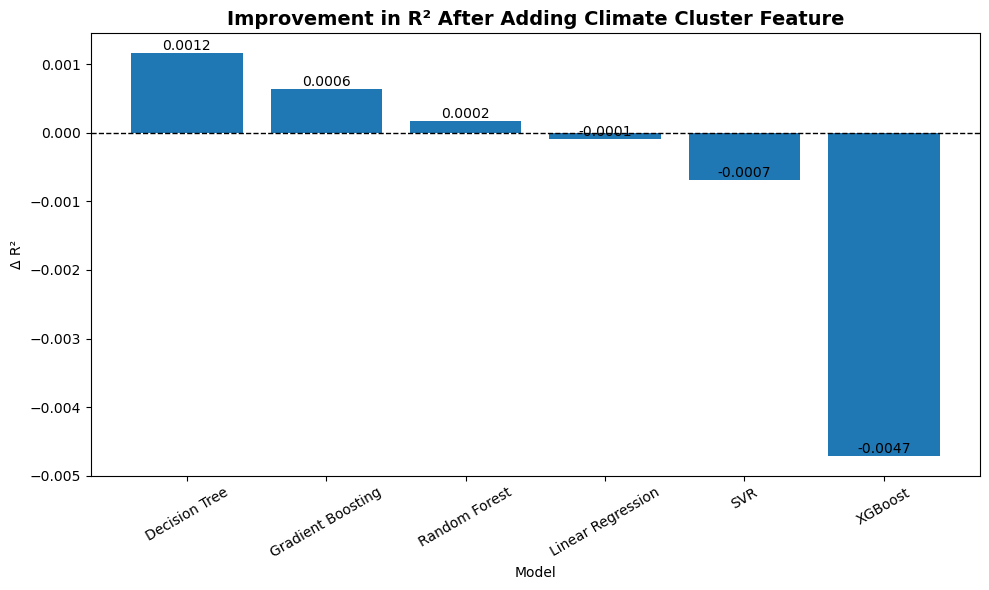

In [ ]:
plt.figure(figsize=(10,6))

comparison_sorted = comparison.sort_values(
    "R2_Improvement",
    ascending=False
)

bars = plt.bar(
    comparison_sorted["Model"],
    comparison_sorted["R2_Improvement"]
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title(
    "Improvement in R² After Adding Climate Cluster Feature",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Δ R²")
plt.xlabel("Model")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

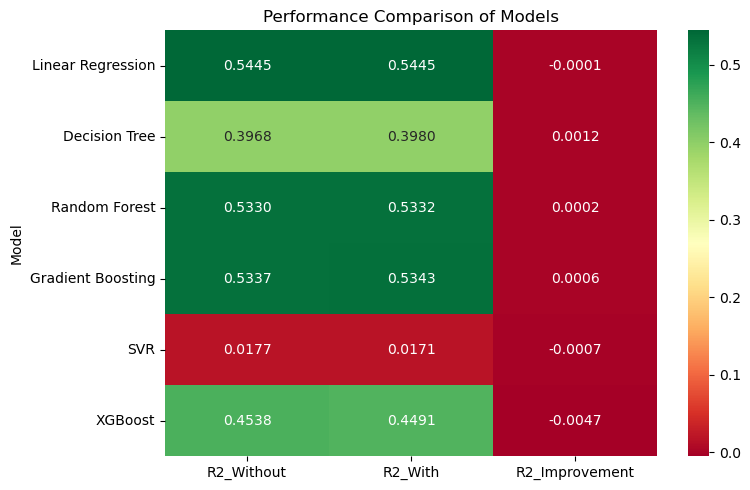

In [ ]:
heatmap_df = comparison[
    [
        "Model",
        "R2_Without",
        "R2_With",
        "R2_Improvement"
    ]
].set_index("Model")

plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".4f",
    cmap="RdYlGn"
)

plt.title(
    "Performance Comparison of Models"
)

plt.tight_layout()
plt.show()

In [ ]:
print(
    "Best Model:",
    comparison.loc[
        comparison["R2_With"].idxmax(),
        "Model"
    ]
)

print(
    "Best R²:",
    comparison["R2_With"].max()
)

Best Model: Linear Regression
Best R²: 0.5444570675729495


## 10. Model Evaluation

### 10.1 Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

best_model = LinearRegression()

cv_scores = cross_val_score(
    best_model,
    X_with_cluster,
    y,
    cv=5,
    scoring="r2"
)

cv_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "R2": cv_scores
})

print("Cross-validation R2 scores:")
print(cv_scores)

print("\nMean R2:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())


Cross-validation R2 scores:
[0.5303696  0.53047719 0.51078313 0.52136888 0.52517118]

Mean R2: 0.523633995271178
Standard Deviation: 0.007277857933270261


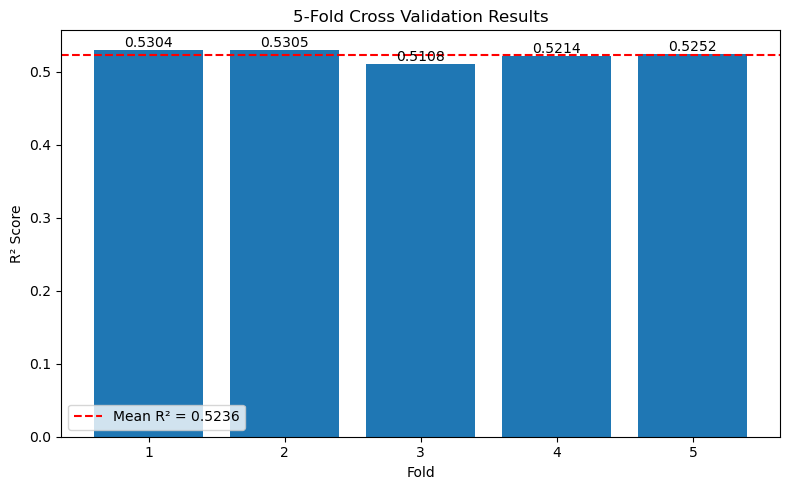

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    cv_results["Fold"],
    cv_results["R2"]
)

plt.axhline(
    cv_scores.mean(),
    color="red",
    linestyle="--",
    label=f"Mean R² = {cv_scores.mean():.4f}"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom"
    )

plt.title("5-Fold Cross Validation Results")
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.legend()
plt.tight_layout()
plt.show()

### 10.2 Coefficient Analysis

In [ ]:
final_lr = LinearRegression()

final_lr.fit(
    X_train_c,
    y_train_c
)

coef_df = pd.DataFrame({
    "Feature": X_with_cluster.columns,
    "Coefficient": final_lr.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

coef_df.head(15)

,Feature,Coefficient,Abs_Coefficient
4,Yield,299.878071,299.878071
36,Region_Patagonia,46.201209,46.201209
50,Region_West,-43.899023,43.899023
33,Region_Nouvelle-Aquitaine,-32.251402,32.251402
28,Region_North Central,29.999854,29.999854
26,Region_New South Wales,27.513618,27.513618
31,Region_Northwest,-27.141551,27.141551
52,Region_Western Australia,-24.699471,24.699471
58,Crop_Type_Soybeans,-24.470629,24.470629
23,Region_Ile-de-France,23.607580,23.607580


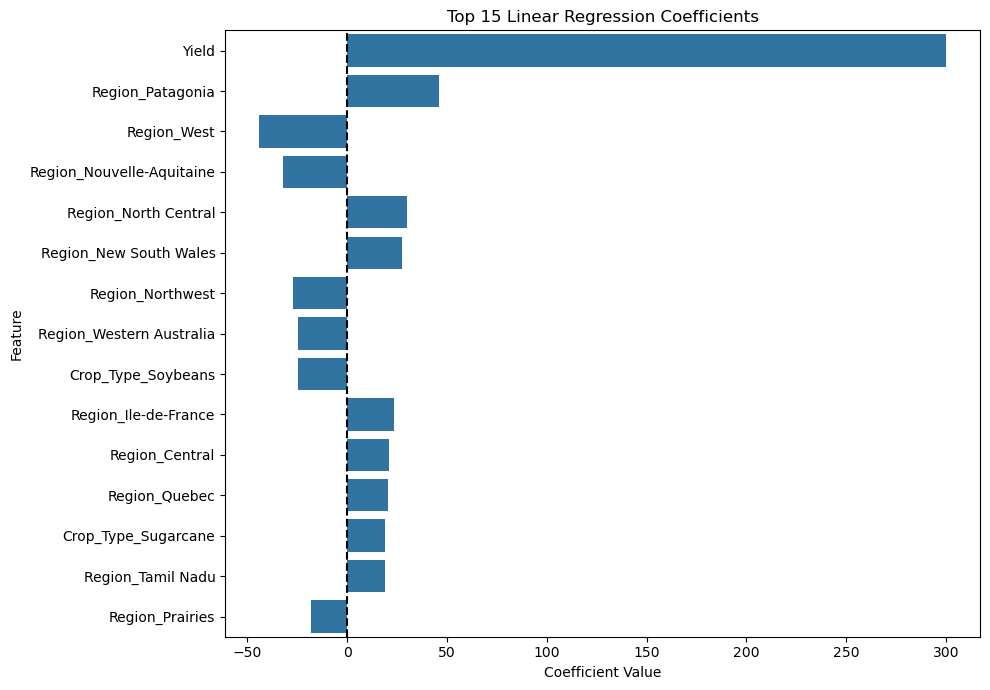

In [ ]:
top_coef = coef_df.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_coef,
    x="Coefficient",
    y="Feature"
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.title("Top 15 Linear Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### 10.3 Factors Affecting Crop Yield

In [ ]:
yield_features = df_model.drop(
    columns=[
        "Yield",
        "EconomicImpact"
    ]
)

yield_y = df_model["Yield"]

X_train_y, X_test_y, y_train_y, y_test_y = train_test_split(
    yield_features,
    yield_y,
    test_size=0.2,
    random_state=42
)

In [ ]:
yield_coef_final = coef_df.copy()

yield_coef_final = yield_coef_final[
    ~yield_coef_final["Feature"].str.contains("Country")
]

yield_coef_final = yield_coef_final[
    ~yield_coef_final["Feature"].str.contains("Region")
]

yield_coef_final = yield_coef_final[
    ~yield_coef_final["Feature"].str.contains("Crop_Type")
]

yield_coef_final = yield_coef_final[
    ~yield_coef_final["Feature"].str.contains("Adaptation")
]

yield_coef_final = yield_coef_final.sort_values(
    "Abs_Coefficient",
    ascending=False
)

yield_coef_final

,Feature,Coefficient,Abs_Coefficient
4,Yield,299.878071,299.878071
10,Cluster,-5.518160,5.518160
3,CO2,0.332839,0.332839
5,ExtremeEvents,0.299351,0.299351
9,SoilHealth,0.258827,0.258827
7,Pesticide,-0.169016,0.169016
8,Fertilizer,0.100530,0.100530
0,Year,-0.087408,0.087408
6,Irrigation,0.047472,0.047472
1,Temperature,-0.013855,0.013855


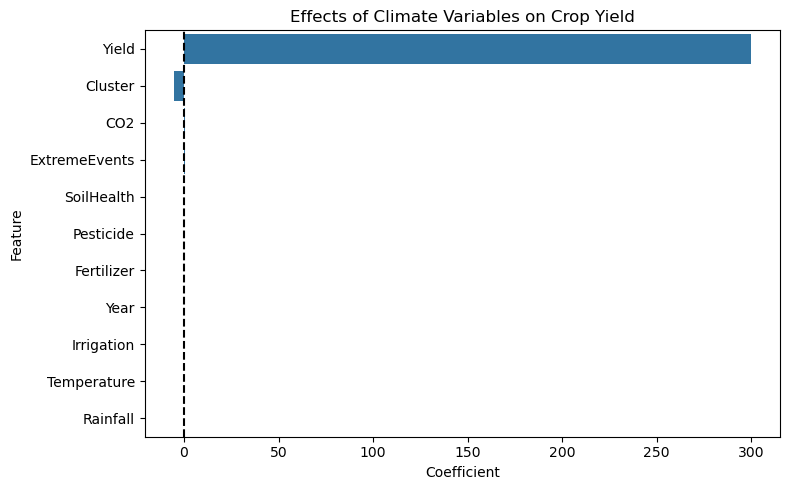

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=yield_coef_final,
    x="Coefficient",
    y="Feature"
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.title(
    "Effects of Climate Variables on Crop Yield"
)

plt.tight_layout()
plt.show()

### 10.4 Residual Analysis

In [ ]:
# 10.3 Residual Analysis

final_lr = LinearRegression()

final_lr.fit(
    X_train_c,
    y_train_c
)

lr_final_pred = final_lr.predict(
    X_test_c
)

residuals = y_test_c - lr_final_pred

residual_df = pd.DataFrame({
    "Actual": y_test_c,
    "Predicted": lr_final_pred,
    "Residual": residuals
})

residual_df.head()

,Actual,Predicted,Residual
6252,116.07,191.593623,-75.523623
4684,1026.14,1248.387229,-222.247229
1731,837.28,751.550108,85.729892
4742,369.90,461.716533,-91.816533
4521,555.35,526.101621,29.248379


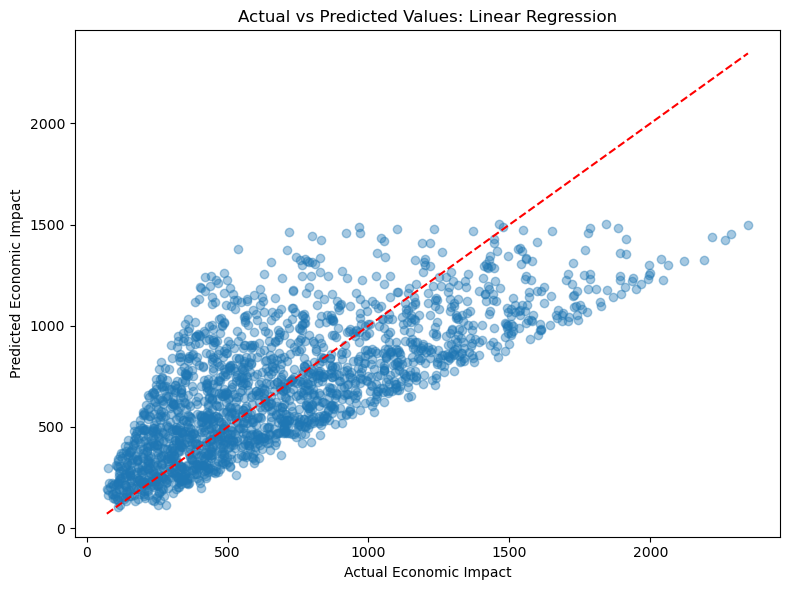

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    residual_df["Actual"],
    residual_df["Predicted"],
    alpha=0.4
)

plt.plot(
    [residual_df["Actual"].min(), residual_df["Actual"].max()],
    [residual_df["Actual"].min(), residual_df["Actual"].max()],
    "r--"
)

plt.xlabel("Actual Economic Impact")
plt.ylabel("Predicted Economic Impact")
plt.title("Actual vs Predicted Values: Linear Regression")

plt.tight_layout()
plt.show()

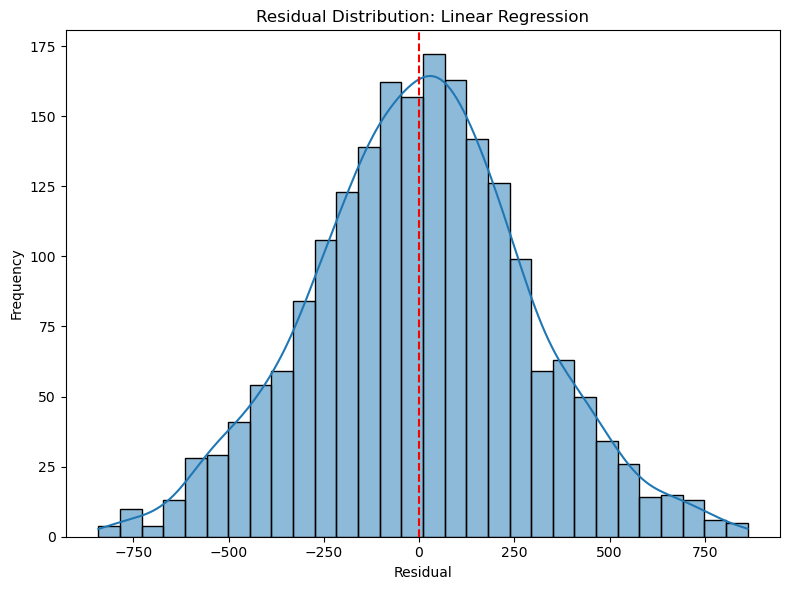

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(
    residual_df["Residual"],
    bins=30,
    kde=True
)

plt.axvline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Residual Distribution: Linear Regression")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

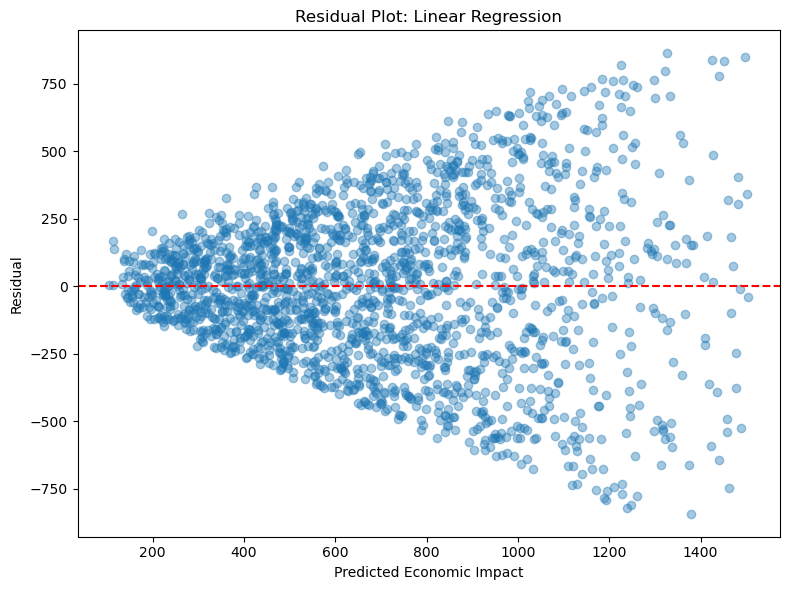

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    residual_df["Predicted"],
    residual_df["Residual"],
    alpha=0.4
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Economic Impact")
plt.ylabel("Residual")
plt.title("Residual Plot: Linear Regression")

plt.tight_layout()
plt.show()

In [ ]:
residual_summary = pd.DataFrame({
    "Metric": [
        "Mean Residual",
        "Standard Deviation",
        "Minimum Residual",
        "Maximum Residual"
    ],
    "Value": [
        residual_df["Residual"].mean(),
        residual_df["Residual"].std(),
        residual_df["Residual"].min(),
        residual_df["Residual"].max()
    ]
})

residual_summary

,Metric,Value
0,Mean Residual,2.785877
1,Standard Deviation,286.705699
2,Minimum Residual,-841.529303
3,Maximum Residual,861.970061


## 11. Hyperparameter Tuning

### 11.1 Random Forest Tuning

In [ ]:
# 11 Hyperparameter Tuning
# Random Forest Tuning

from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(
    X_train_c,
    y_train_c
)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Random Forest CV R2:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Best Random Forest CV R2:
0.5160568635688831


In [ ]:
best_rf = rf_grid.best_estimator_

best_rf_pred = best_rf.predict(
    X_test_c
)

best_rf_mae = mean_absolute_error(
    y_test_c,
    best_rf_pred
)

best_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test_c,
        best_rf_pred
    )
)

best_rf_r2 = r2_score(
    y_test_c,
    best_rf_pred
)

print("Tuned Random Forest Test Results")
print("MAE:", best_rf_mae)
print("RMSE:", best_rf_rmse)
print("R2:", best_rf_r2)

Tuned Random Forest Test Results
MAE: 224.3260574812189
RMSE: 285.9088259296507
R2: 0.5468020207516453


### 11.2 XGBoost Tuning

In [ ]:
# 11.2 XGBoost Tuning

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_grid=xgb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

xgb_grid.fit(
    X_train_c,
    y_train_c
)

print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

print("\nBest XGBoost CV R2:")
print(xgb_grid.best_score_)

Best XGBoost Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

Best XGBoost CV R2:
0.5161739551582418


In [ ]:
best_xgb = xgb_grid.best_estimator_

best_xgb_pred = best_xgb.predict(
    X_test_c
)

best_xgb_mae = mean_absolute_error(
    y_test_c,
    best_xgb_pred
)

best_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test_c,
        best_xgb_pred
    )
)

best_xgb_r2 = r2_score(
    y_test_c,
    best_xgb_pred
)

print("Tuned XGBoost Test Results")
print("MAE:", best_xgb_mae)
print("RMSE:", best_xgb_rmse)
print("R2:", best_xgb_r2)

Tuned XGBoost Test Results
MAE: 225.71225898315433
RMSE: 287.1574025047796
R2: 0.5428351062626344


### 11.3 Tuned vs Untuned Comparison

In [ ]:
# 11.3 Tuned vs Untuned Comparison

untuned_rf = results_with.loc[
    results_with["Model"] == "Random Forest"
].iloc[0]

untuned_xgb = results_with.loc[
    results_with["Model"] == "XGBoost"
].iloc[0]

tuning_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost",
        "Tuned XGBoost",
        "Linear Regression"
    ],
    "MAE": [
        untuned_rf["MAE"],
        best_rf_mae,
        untuned_xgb["MAE"],
        best_xgb_mae,
        results_with.loc[
            results_with["Model"] == "Linear Regression",
            "MAE"
        ].values[0]
    ],
    "RMSE": [
        untuned_rf["RMSE"],
        best_rf_rmse,
        untuned_xgb["RMSE"],
        best_xgb_rmse,
        results_with.loc[
            results_with["Model"] == "Linear Regression",
            "RMSE"
        ].values[0]
    ],
    "R2": [
        untuned_rf["R2"],
        best_rf_r2,
        untuned_xgb["R2"],
        best_xgb_r2,
        results_with.loc[
            results_with["Model"] == "Linear Regression",
            "R2"
        ].values[0]
    ]
})

tuning_comparison.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
1,Tuned Random Forest,224.326057,285.908826,0.546802
4,Linear Regression,225.691048,286.647551,0.544457
3,Tuned XGBoost,225.712259,287.157403,0.542835
0,Random Forest,226.363611,290.180521,0.533159
2,XGBoost,245.096195,315.214436,0.449135


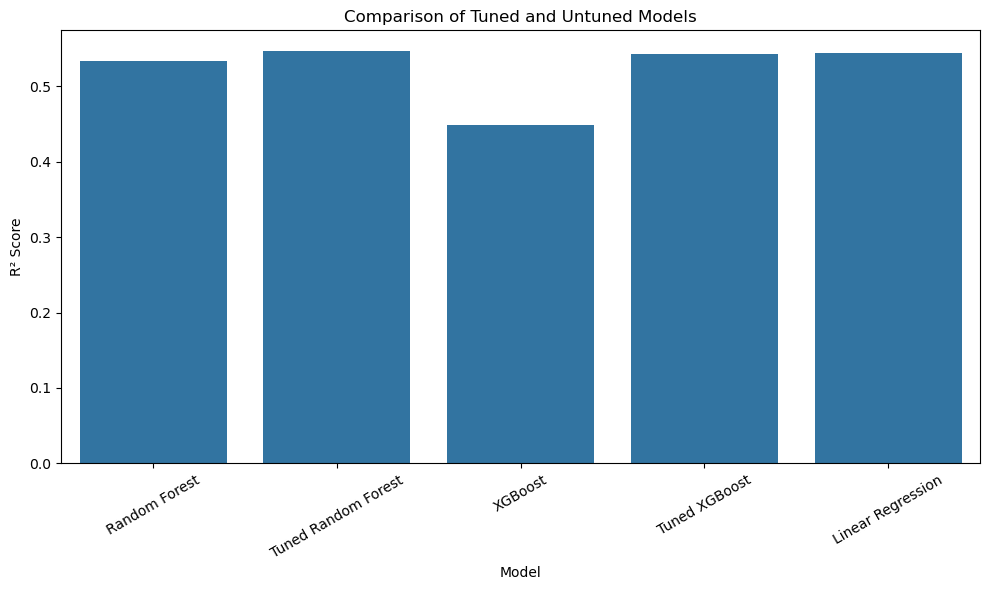

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=tuning_comparison,
    x="Model",
    y="R2"
)

plt.title("Comparison of Tuned and Untuned Models")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
tuning_comparison.to_csv(
    "tuning_comparison_results.csv",
    index=False
)

print("Tuning comparison results saved.")

Tuning comparison results saved.


Tuned Random Forest Test Performance
MAE:  224.326
RMSE: 285.909
R²:   0.5468


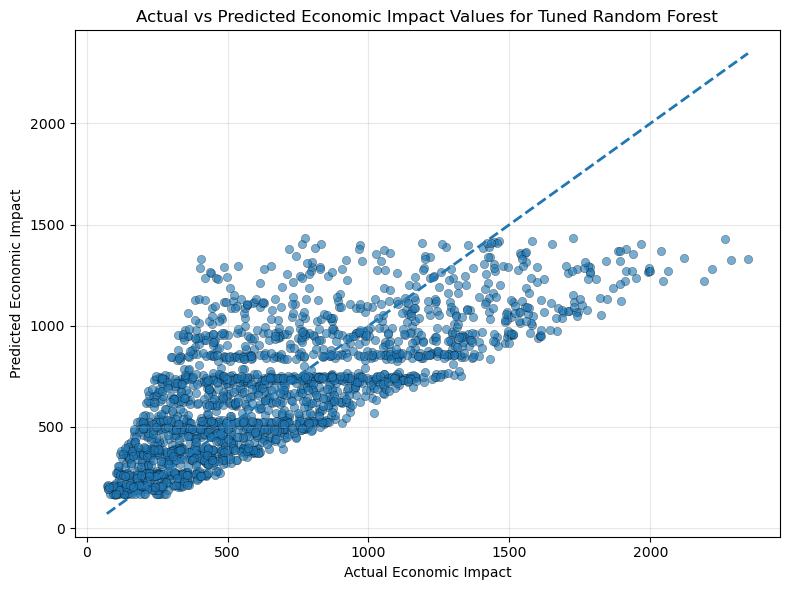

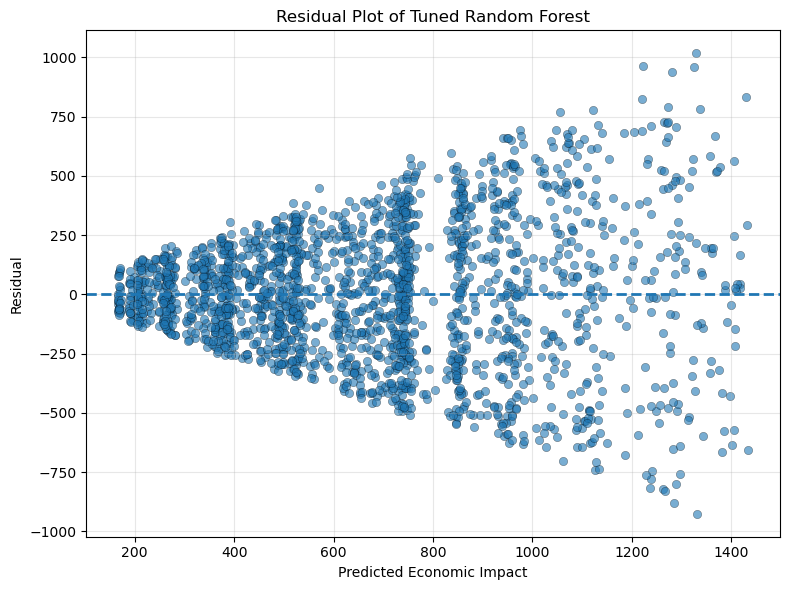

In [ ]:
# Prediction Error Analysis for Tuned Random Forest

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Final tuned Random Forest model
final_rf_model = rf_grid.best_estimator_

# Generate predictions using the same test set used for the tuned model
y_pred_rf = final_rf_model.predict(X_test_c)

# Evaluation metrics
mae_rf = mean_absolute_error(y_test_c, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_c, y_pred_rf))
r2_rf = r2_score(y_test_c, y_pred_rf)

print("Tuned Random Forest Test Performance")
print(f"MAE:  {mae_rf:.3f}")
print(f"RMSE: {rmse_rf:.3f}")
print(f"R²:   {r2_rf:.4f}")


plt.figure(figsize=(8, 6))

plt.scatter(y_test_c, y_pred_rf, alpha=0.6, edgecolors="k", linewidths=0.3)

min_value = min(min(y_test_c), min(y_pred_rf))
max_value = max(max(y_test_c), max(y_pred_rf))

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--", linewidth=2)

plt.xlabel("Actual Economic Impact")
plt.ylabel("Predicted Economic Impact")
plt.title("Actual vs Predicted Economic Impact Values for Tuned Random Forest")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("Figure_5_6_Actual_vs_Predicted_Tuned_RF.png", dpi=300, bbox_inches="tight")
plt.show()


residuals_rf = y_test_c - y_pred_rf

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_rf, residuals_rf, alpha=0.6, edgecolors="k", linewidths=0.3)
plt.axhline(y=0, linestyle="--", linewidth=2)

plt.xlabel("Predicted Economic Impact")
plt.ylabel("Residual")
plt.title("Residual Plot of Tuned Random Forest")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("Figure_5_7_Residual_Plot_Tuned_RF.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

tuned_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(
    tuned_rf,
    X_train_c,
    y_train_c,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Fold R² scores:", cv_scores)
print("Mean R²:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Fold R² scores: [0.52228911 0.53791926 0.50480656 0.50199496 0.51327443]
Mean R²: 0.5160568635688831
Standard deviation: 0.013029610409414132


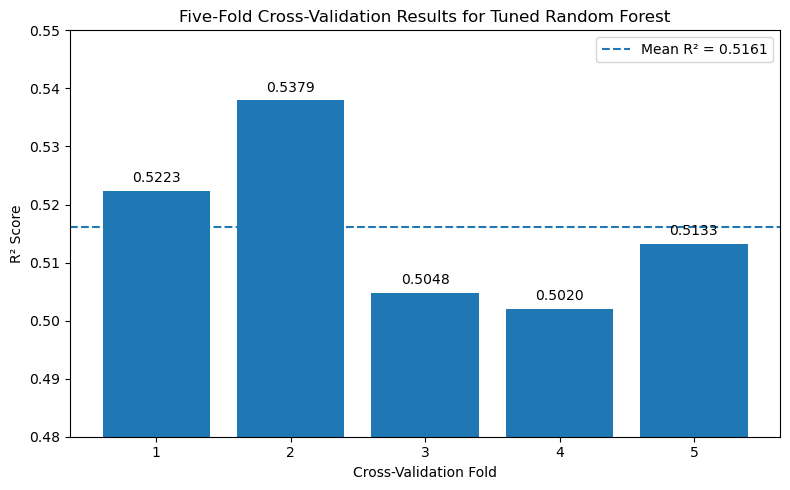

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

folds = np.arange(1, 6)
cv_scores = np.array([
    0.52228911,
    0.53791926,
    0.50480656,
    0.50199496,
    0.51327443
])

mean_r2 = cv_scores.mean()

plt.figure(figsize=(8, 5))

plt.bar(folds, cv_scores)

plt.axhline(
    y=mean_r2,
    linestyle="--",
    label=f"Mean R² = {mean_r2:.4f}"
)

for i, score in enumerate(cv_scores):
    plt.text(
        folds[i],
        score + 0.001,
        f"{score:.4f}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Cross-Validation Fold")
plt.ylabel("R² Score")
plt.title("Five-Fold Cross-Validation Results for Tuned Random Forest")
plt.xticks(folds)
plt.ylim(0.48, 0.55)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
cluster_summary = df.groupby("Cluster").agg(
    Number_of_Observations=("Cluster", "size"),
    Temperature=("Temperature", "mean"),
    Rainfall=("Rainfall", "mean"),
    CO2=("CO2", "mean"),
    ExtremeEvents=("ExtremeEvents", "mean"),
    Irrigation=("Irrigation", "mean"),
    SoilHealth=("SoilHealth", "mean"),
    EconomicImpact=("EconomicImpact", "mean")
).reset_index()

cluster_summary = cluster_summary.round(3)
print(cluster_summary)

   Cluster  Number_of_Observations  Temperature  Rainfall     CO2  \
0        0                    2495       24.685  1671.693  14.829   
1        1                    2484        5.559  2358.252  15.308   
2        2                    2467       24.516  1616.833  15.617   
3        3                    2554        6.474   821.902  15.237   

   ExtremeEvents  Irrigation  SoilHealth  EconomicImpact  
0          1.976      54.024      61.101         744.136  
1          5.186      56.257      65.069         605.320  
2          8.019      53.657      66.100         746.849  
3          4.782      57.001      67.293         602.970  
